# Gesture Dataset Loading and LSTM Training
This notebook loads gesture datasets from the `custom` and `xml_logs` folders, compares their contents, and trains an LSTM model on the xml_logs dataset.  
This LSTM model is then evaluated with different hyperparameters and compared to the $1 unistroke recognizer.  

## Init

In [ ]:
import os
from collections import Counter, defaultdict
import numpy as np
import xml.etree.ElementTree as ET
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from recognizer.recognizer import Recognizer
import time
import pandas as pd
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)


# Helper: Parse points from XML file
def parse_gesture_xml(file_path):
    xml_root = ET.parse(file_path).getroot()
    points = []
    for element in xml_root.findall("Point"):
        x = float(element.get("X"))
        y = float(element.get("Y"))
        points.append([x, y])
    return np.array(points, dtype=float), file_path

## 2. Load Custom and xml_logs Datasets
Load gesture data from both the `datasets/custom` and `datasets/xml_logs` directories. Parse XML files and load the data into pandas DataFrames or numpy arrays.

All loaded gestures are normalized in the same way for both recognizer and LSTM that will later be trained and evaluated.

In [18]:
# Paths to datasets
datasets_dir = "datasets"
custom_dir = os.path.join(datasets_dir, "custom")
xml_logs_dir = os.path.join(datasets_dir, "xml_logs")
helper_recognizer = Recognizer()  # Assuming this is defined elsewhere


# Helper: Recursively find all XML files in a directory
def find_xml_files(root_dir):
    return [y for x in os.walk(root_dir) for y in glob(os.path.join(x[0], "*.xml"))]


# Load custom dataset and normalize
custom_files = find_xml_files(custom_dir)
custom_data = []
custom_labels = []
for file in custom_files:
    points, path = parse_gesture_xml(file)
    norm_points, _ = helper_recognizer.normalize(points)
    label = os.path.basename(file).split(".")[0][:-2]
    custom_data.append(norm_points)
    custom_labels.append(label)

# Load xml_logs dataset and normalize
xml_logs_files = find_xml_files(xml_logs_dir)
xml_logs_data = []
xml_logs_labels = []
for file in xml_logs_files:
    points, path = parse_gesture_xml(file)
    norm_points, _ = helper_recognizer.normalize(points)
    label = os.path.basename(file).split(".")[0][:-2]
    xml_logs_data.append(norm_points)
    xml_logs_labels.append(label)

print(f"Loaded {len(custom_data)} samples from custom, {len(xml_logs_data)} from xml_logs.")

Loading gesture templates (Sync): [------------------------------] 30/5280

Loading gesture templates (Sync): [==============================] 5280/5280

Loaded 52 samples from custom, 5280 from xml_logs.
Loaded 52 samples from custom, 5280 from xml_logs.


## 3. Limit Dataset Size to Smallest Dataset
To ensure a fair comparison, limit both datasets to the size of the smaller one.  
They have already been normalized, so there are no differences besides the data itself.  
Below this code cell are a few metrics to show that the datasets are loaded correctly with the same dimensions and format.

Symmetrical datasets created with 52 samples per dataset.


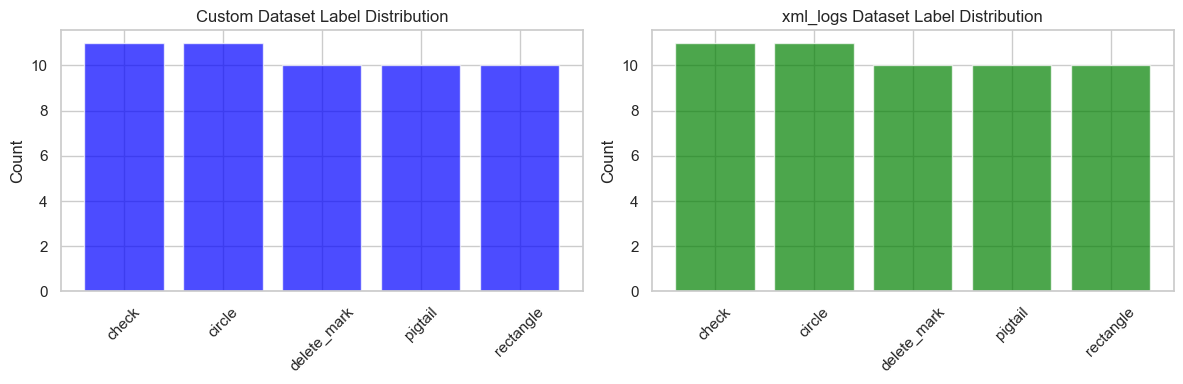

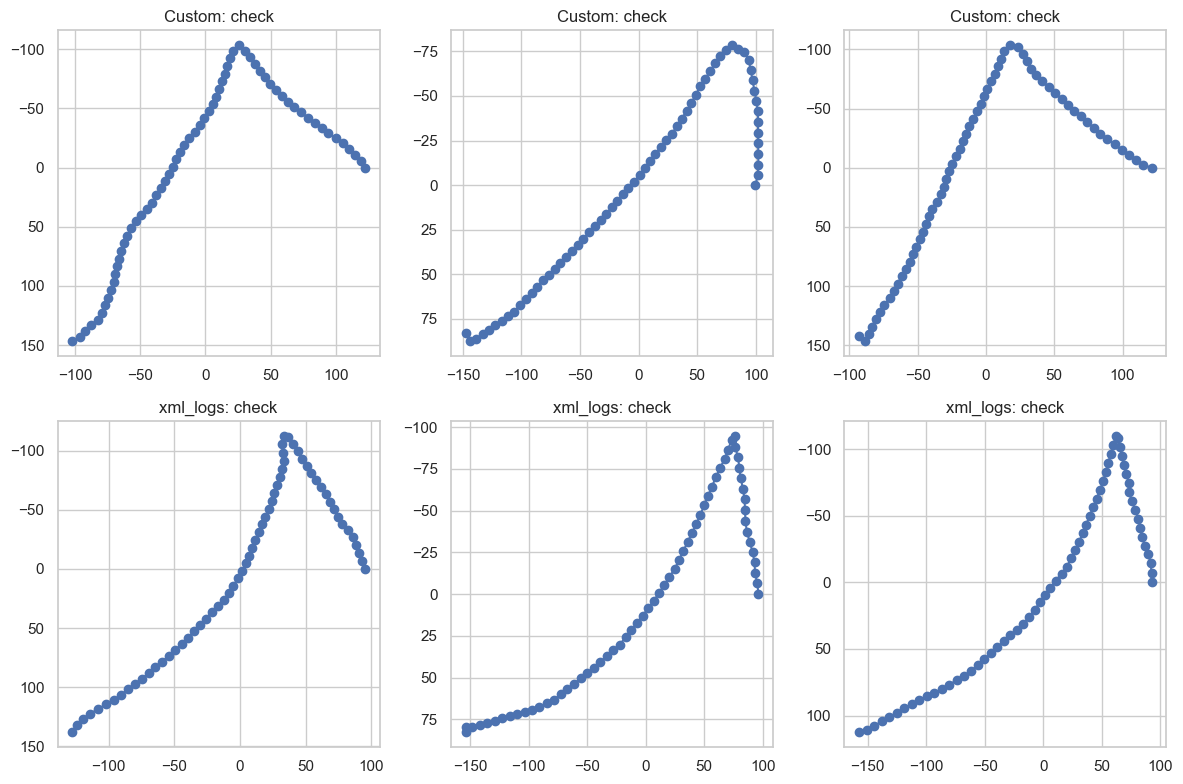

In [ ]:
# Truncate both datasets so that for each label, the number of samples is the minimum count for that label across both datasets
# Count occurrences of each label in both datasets
custom_counts = Counter(custom_labels)
xml_logs_counts = Counter(xml_logs_labels)

# Find common labels
common_labels = set(custom_counts.keys()) & set(xml_logs_counts.keys())


# For each label, keep only the minimum number of samples in both datasets
def filter_to_min_samples(data, labels, min_counts):
    filtered_data = []
    filtered_labels = []
    label_counter = defaultdict(int)
    for d, l in zip(data, labels):  # noqa: E741
        if l in min_counts and label_counter[l] < min_counts[l]:
            filtered_data.append(d)
            filtered_labels.append(l)
            label_counter[l] += 1
    return filtered_data, filtered_labels


min_counts = {label: min(custom_counts[label], xml_logs_counts[label]) for label in common_labels}

custom_data_sym, custom_labels_sym = filter_to_min_samples(custom_data, custom_labels, min_counts)
xml_logs_data_sym, xml_logs_labels_sym = filter_to_min_samples(
    xml_logs_data, xml_logs_labels, min_counts
)

print(f"Symmetrical datasets created with {sum(min_counts.values())} samples per dataset.")
# Plot label distributions
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

custom_label_counts = Counter(custom_labels_sym)
xml_logs_label_counts = Counter(xml_logs_labels_sym)

axs[0].bar(custom_label_counts.keys(), custom_label_counts.values(), color="blue", alpha=0.7)
axs[0].set_title("Custom Dataset Label Distribution")
axs[0].set_ylabel("Count")
axs[0].set_xticks(range(len(custom_label_counts)))
axs[0].set_xticklabels(list(custom_label_counts.keys()), rotation=45)

axs[1].bar(xml_logs_label_counts.keys(), xml_logs_label_counts.values(), color="green", alpha=0.7)
axs[1].set_title("xml_logs Dataset Label Distribution")
axs[1].set_ylabel("Count")
axs[1].set_xticks(range(len(xml_logs_label_counts)))
axs[1].set_xticklabels(list(xml_logs_label_counts.keys()), rotation=45)

plt.tight_layout()
plt.show()

# Show a few gesture samples from both datasets
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    axs[0, i].plot(
        np.array(custom_data_sym[i])[:, 0], np.array(custom_data_sym[i])[:, 1], marker="o"
    )
    axs[0, i].set_title(f"Custom: {custom_labels_sym[i]}")
    axs[0, i].invert_yaxis()
    axs[1, i].plot(
        np.array(xml_logs_data_sym[i])[:, 0], np.array(xml_logs_data_sym[i])[:, 1], marker="o"
    )
    axs[1, i].set_title(f"xml_logs: {xml_logs_labels_sym[i]}")
    axs[1, i].invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Load Full xml_logs Dataset
Load the entire xml_logs dataset (not truncated) for LSTM training.

In [20]:
# Reload the entire xml_logs dataset for LSTM training
xml_logs_files_full = find_xml_files(xml_logs_dir)
xml_logs_data_full = []
xml_logs_labels_full = []
for file in xml_logs_files_full:
    points, path = parse_gesture_xml(file)
    label = os.path.basename(file).split(".")[0][:-2]
    xml_logs_data_full.append(points)
    xml_logs_labels_full.append(label)

print(f"Loaded {len(xml_logs_data_full)} samples from full xml_logs dataset.")

Loaded 5280 samples from full xml_logs dataset.


## 5. Preprocess Data for LSTM Training
Normalize and reshape the gesture data as required for LSTM input. Encode labels and split the data into training and validation sets.

In [21]:
# max sequence length
max_len = 64


def normalize_points(points, target_len=64):
    # Resample to fixed number of points
    points = np.array(points)
    if len(points) == 0:
        return np.zeros((target_len, 2))
    if len(points) == target_len:
        return points
    # Linear interpolation for resampling
    idxs = np.linspace(0, len(points) - 1, target_len)
    resampled = np.vstack(
        [
            np.interp(idxs, np.arange(len(points)), points[:, 0]),
            np.interp(idxs, np.arange(len(points)), points[:, 1]),
        ]
    ).T
    return resampled


X = np.array(xml_logs_data)
le = LabelEncoder()
y = le.fit_transform(xml_logs_labels)
y_cat = to_categorical(y)

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (4224, 64, 2), y_train shape: (4224, 16)


## 6. Build and Train LSTM Model
Define and train an LSTM model using TensorFlow/Keras on the preprocessed xml_logs dataset.

In [ ]:
# Define LSTM model
num_classes = y_cat.shape[1]
num_lstm_layers = 1


def get_layer_set(return_sequences=False, num_layers=1):
    if num_layers <= 0:
        return []
    return [
        LSTM(64, return_sequences=(num_layers > 1 or return_sequences)),
        Dropout(0.3),
        *get_layer_set(return_sequences=return_sequences, num_layers=num_layers - 1),
    ]


model = Sequential(
    [
        Input(shape=(max_len, 2)),
        *get_layer_set(return_sequences=False, num_layers=num_lstm_layers),
        Dense(num_classes, activation="softmax"),
    ]
)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# Train the model
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,192 (71.06 KB)

 Trainable params: 18,192 (71.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3293 - loss: 2.1994 - val_accuracy: 0.7339 - val_loss: 0.9814
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3293 - loss: 2.1994 - val_accuracy: 0.7339 - val_loss: 0.9814
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7317 - loss: 0.9404 - val_accuracy: 0.8551 - val_loss: 0.5905
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7317 - loss: 0.9404 - val_accuracy: 0.8551 - val_loss: 0.5905
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8451 - loss: 0.5942 - val_accuracy: 0.9205 - val_loss: 0.3914
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8451 - loss: 0.5942 - val_accuracy: 0.9205 - val_loss: 0.3914
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8959 - loss: 0.4095 - val_accuracy: 0.9280 - val_loss: 0.2796
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8959 - loss: 0.4095 - val_accu

## 6.1. Train Additional LSTM Models with Different Layer Configurations
Let's train two more LSTM models with different numbers of layer sets (2 and 3) to compare their performance:

In [ ]:
# Train LSTM model with 2 layer sets
num_lstm_layers_2 = 2
model_2layers = Sequential(
    [
        Input(shape=(max_len, 2)),
        *get_layer_set(return_sequences=False, num_layers=num_lstm_layers_2),
        Dense(num_classes, activation="softmax"),
    ]
)

model_2layers.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_2layers.summary()

# Train the model with 2 layer sets
early_stopping_2 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history_2layers = model_2layers.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_2],
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 64, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,216 (200.06 KB)

 Trainable params: 51,216 (200.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5366 - loss: 1.6811 - val_accuracy: 0.8835 - val_loss: 0.3053
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9304 - loss: 0.2617 - val_accuracy: 0.9545 - val_loss: 0.1728
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9638 - loss: 0.1385 - val_accuracy: 0.9716 - val_loss: 0.1136
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9762 - loss: 0.1024 - val_accuracy: 0.9697 - val_loss: 0.1110
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9814 - loss: 0.0785 - val_accuracy: 0.9725 - val_loss: 0.0936
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9825 - loss: 0.0718 - val_accuracy: 0.9564 - val_loss: 0.1382
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9849 - loss: 0.0580 - val_accuracy: 0.9612 - val_loss: 0.1110
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9815 - loss: 0.0644 - val_accu

In [ ]:
# Train LSTM model with 3 layer sets
num_lstm_layers_3 = 3
model_3layers = Sequential(
    [
        Input(shape=(max_len, 2)),
        *get_layer_set(return_sequences=False, num_layers=num_lstm_layers_3),
        Dense(num_classes, activation="softmax"),
    ]
)

model_3layers.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_3layers.summary()

# Train the model with 3 layer sets
early_stopping_3 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history_3layers = model_3layers.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_3],
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 64, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,240 (329.06 KB)

 Trainable params: 84,240 (329.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.5568 - loss: 1.6015 - val_accuracy: 0.8845 - val_loss: 0.2636
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9183 - loss: 0.2596 - val_accuracy: 0.9328 - val_loss: 0.1722
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9579 - loss: 0.1666 - val_accuracy: 0.9706 - val_loss: 0.1121
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9547 - loss: 0.1485 - val_accuracy: 0.9659 - val_loss: 0.1025
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9702 - loss: 0.1120 - val_accuracy: 0.9574 - val_loss: 0.1812
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9713 - loss: 0.1049 - val_accuracy: 0.9744 - val_loss: 0.1007
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9797 - loss: 0.0746 - val_accuracy: 0.9773 - val_loss: 0.0774
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9780 - loss: 0.0804 - val_accu

## 7. Evaluate accuracy and inference time of LSTM Model and Dollar Recognizer

In [32]:
# Evaluate $1 recognizer on truncated custom and xml_logs datasets


def eval_recognizer_on_dataset(data, labels, recognizer, max_len):
    correct_list = []
    inference_times = []
    for points, label in zip(data, labels):
        start_time = time.perf_counter()
        pred_label, *_ = recognizer.recognize(points)
        inference_times.append(time.perf_counter() - start_time)
        correct_list.append(pred_label == label)
    return correct_list, inference_times


# Train recognizer on custom_data
recognizer_custom = Recognizer(num_points=max_len, load_dataset=False)
for points, label in zip(custom_data_sym, custom_labels_sym):
    recognizer_custom.add_custom_template(label, points, times=None)

# Train recognizer on xml_logs_data
recognizer_xml = Recognizer(num_points=max_len, load_dataset=False)
for points, label in zip(xml_logs_data_sym, xml_logs_labels_sym):
    recognizer_xml.add_custom_template(label, points, times=None)

# Evaluate on custom_data
acc_custom, time_custom = eval_recognizer_on_dataset(
    custom_data_sym, custom_labels_sym, recognizer_custom, max_len
)
print(
    f"$1 Recognizer on custom_data: Mean Accuracy={np.mean(acc_custom):.4f}, Mean Inference Time={np.mean(time_custom):.6f} s"
)

# Evaluate on xml_logs_data
acc_xml, time_xml = eval_recognizer_on_dataset(
    xml_logs_data_sym, xml_logs_labels_sym, recognizer_xml, max_len
)
print(
    f"$1 Recognizer on xml_logs_data: Mean Accuracy={np.mean(acc_xml):.4f}, Mean Inference Time={np.mean(time_xml):.6f} s"
)

$1 Recognizer on custom_data: Mean Accuracy=1.0000, Mean Inference Time=0.001727 s
$1 Recognizer on xml_logs_data: Mean Accuracy=1.0000, Mean Inference Time=0.002326 s

$1 Recognizer on xml_logs_data: Mean Accuracy=1.0000, Mean Inference Time=0.002326 s


In [33]:
# Evaluate LSTM on truncated custom and xml_logs datasets


def prepare_lstm_data(data, labels, max_len, le):
    X = np.array([normalize_points(p, max_len) for p in data])
    y = le.transform(labels)
    y_cat = to_categorical(y, num_classes=len(le.classes_))
    return X, y, y_cat


# Prepare data
X_custom, y_custom_enc, y_custom_cat = prepare_lstm_data(
    custom_data_sym, custom_labels_sym, max_len, le
)
X_xml, y_xml_enc, y_xml_cat = prepare_lstm_data(xml_logs_data_sym, xml_logs_labels_sym, max_len, le)


def eval_lstm_on_dataset(X, y, le, model):
    correct_list = []
    inference_times = []
    for points, true_idx in zip(X, y):
        start_time = time.perf_counter()
        pred_probs = model.predict(points[np.newaxis, ...], verbose=0)
        pred_label = np.argmax(pred_probs)
        inference_times.append(time.perf_counter() - start_time)
        correct_list.append(pred_label == true_idx)
    return correct_list, inference_times


# Evaluate LSTM (1 layer) on custom_data
lstm_acc_custom, lstm_time_custom = eval_lstm_on_dataset(X_custom, y_custom_enc, le, model)
print(
    f"LSTM (1 layer) on custom_data: Accuracy={np.mean(lstm_acc_custom):.4f}, Mean Inference Time={np.mean(lstm_time_custom):.6f} s"
)

# Evaluate LSTM (1 layer) on xml_logs_data
lstm_acc_xml, lstm_time_xml = eval_lstm_on_dataset(X_xml, y_xml_enc, le, model)
print(
    f"LSTM (1 layer) on xml_logs_data: Accuracy={np.mean(lstm_acc_xml):.4f}, Mean Inference Time={np.mean(lstm_time_xml):.6f} s"
)

# Evaluate LSTM (2 layers) on custom_data
lstm_acc_custom_2layers, lstm_time_custom_2layers = eval_lstm_on_dataset(
    X_custom, y_custom_enc, le, model_2layers
)
print(
    f"LSTM (2 layers) on custom_data: Accuracy={np.mean(lstm_acc_custom_2layers):.4f}, Mean Inference Time={np.mean(lstm_time_custom_2layers):.6f} s"
)

# Evaluate LSTM (2 layers) on xml_logs_data
lstm_acc_xml_2layers, lstm_time_xml_2layers = eval_lstm_on_dataset(
    X_xml, y_xml_enc, le, model_2layers
)
print(
    f"LSTM (2 layers) on xml_logs_data: Accuracy={np.mean(lstm_acc_xml_2layers):.4f}, Mean Inference Time={np.mean(lstm_time_xml_2layers):.6f} s"
)

# Evaluate LSTM (3 layers) on custom_data
lstm_acc_custom_3layers, lstm_time_custom_3layers = eval_lstm_on_dataset(
    X_custom, y_custom_enc, le, model_3layers
)
print(
    f"LSTM (3 layers) on custom_data: Accuracy={np.mean(lstm_acc_custom_3layers):.4f}, Mean Inference Time={np.mean(lstm_time_custom_3layers):.6f} s"
)

# Evaluate LSTM (3 layers) on xml_logs_data
lstm_acc_xml_3layers, lstm_time_xml_3layers = eval_lstm_on_dataset(
    X_xml, y_xml_enc, le, model_3layers
)
print(
    f"LSTM (3 layers) on xml_logs_data: Accuracy={np.mean(lstm_acc_xml_3layers):.4f}, Mean Inference Time={np.mean(lstm_time_xml_3layers):.6f} s"
)

LSTM (1 layer) on custom_data: Accuracy=0.8077, Mean Inference Time=0.055255 s
LSTM (1 layer) on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.056994 s
LSTM (1 layer) on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.056994 s
LSTM (2 layers) on custom_data: Accuracy=0.8462, Mean Inference Time=0.063532 s
LSTM (2 layers) on custom_data: Accuracy=0.8462, Mean Inference Time=0.063532 s
LSTM (2 layers) on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.064351 s
LSTM (2 layers) on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.064351 s
LSTM (3 layers) on custom_data: Accuracy=0.7885, Mean Inference Time=0.065583 s
LSTM (3 layers) on custom_data: Accuracy=0.7885, Mean Inference Time=0.065583 s
LSTM (3 layers) on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.059116 s
LSTM (3 layers) on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.059116 s


### 7.1 Prepare Data for Evaluation

In [36]:
records = []


# Helper function to add results to a list of dicts
def add_records(model_name, dataset_name, correct_list, time_list):
    for correct, t in zip(correct_list, time_list):
        records.append(
            {
                "model": model_name,
                "dataset": dataset_name,
                "accuracy": int(correct),  # 0 or 1
                "inference_time": t,
            }
        )


# Add results from each test:
add_records("LSTM-1layer", "custom", lstm_acc_custom, lstm_time_custom)
add_records("LSTM-1layer", "xml", lstm_acc_xml, lstm_time_xml)
add_records("LSTM-2layers", "custom", lstm_acc_custom_2layers, lstm_time_custom_2layers)
add_records("LSTM-2layers", "xml", lstm_acc_xml_2layers, lstm_time_xml_2layers)
add_records("LSTM-3layers", "custom", lstm_acc_custom_3layers, lstm_time_custom_3layers)
add_records("LSTM-3layers", "xml", lstm_acc_xml_3layers, lstm_time_xml_3layers)
add_records("$1", "custom", acc_custom, time_custom)
add_records("$1", "xml", acc_xml, time_xml)

# Convert to DataFrame
df = pd.DataFrame(records)

print(df.head())

         model dataset  accuracy  inference_time
0  LSTM-1layer  custom         1        0.142429
1  LSTM-1layer  custom         1        0.051762
2  LSTM-1layer  custom         1        0.056670
3  LSTM-1layer  custom         1        0.052778
4  LSTM-1layer  custom         1        0.054517


## 8. Compare and Plot Performance

Below are some plots to visualize the performance of the LSTM model and the $1 unistroke recognizer.  
I also performed a two-way ANOVA test to compare the performance of the two models and datasets.

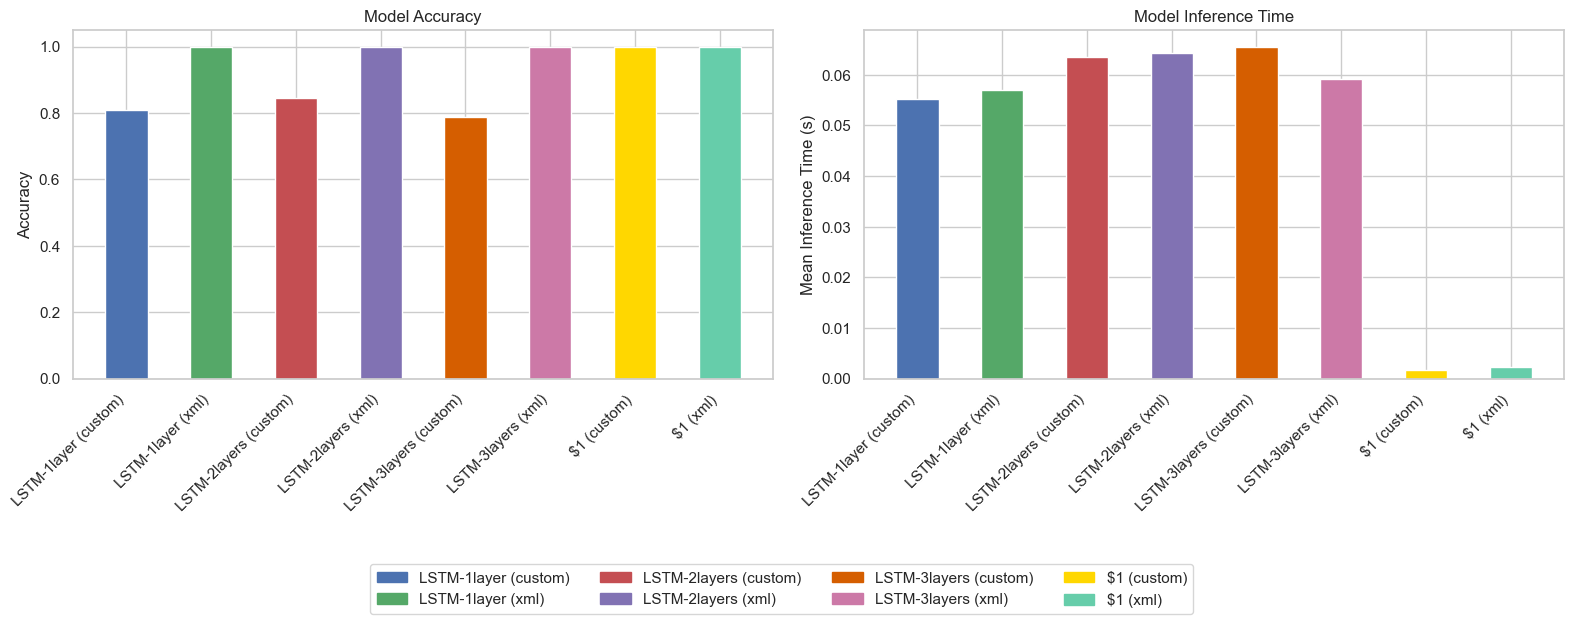

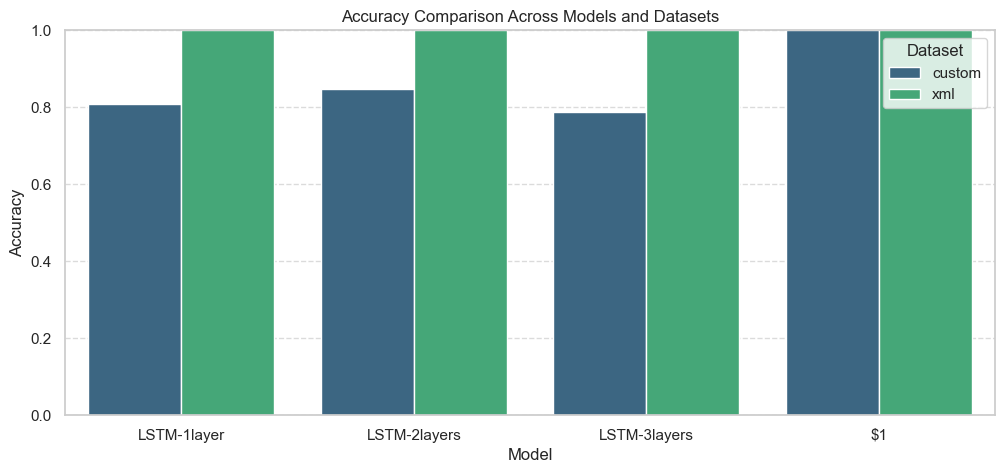

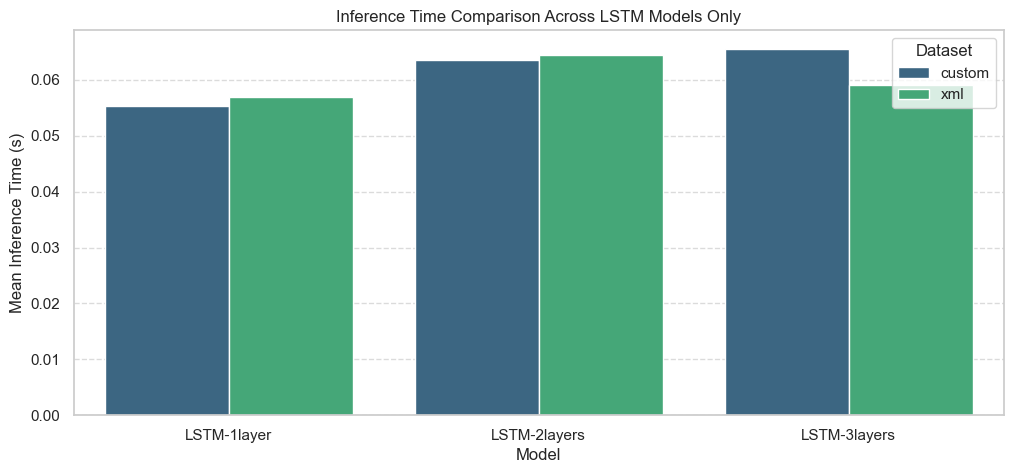

Two-way ANOVA: Accuracy
                       sum_sq         df         F   PR(>F)
C(model)             0.718750   3.000000  4.156173 0.006433
C(dataset)           2.021635   1.000000 35.070319 0.000000
C(model):C(dataset)  0.718750   3.000000  4.156173 0.006433
Residual            23.519231 408.000000       NaN      NaN

Two-way ANOVA: Inference Time
                      sum_sq         df          F   PR(>F)
C(model)            0.273035   3.000000 444.854692 0.000000
C(dataset)          0.000071   1.000000   0.347915 0.555622
C(model):C(dataset) 0.001122   3.000000   1.827288 0.141537
Residual            0.083472 408.000000        NaN      NaN


In [ ]:
# Calculate mean accuracy and mean inference time for each (model, dataset) pair from the DataFrame
model_names = [
    "LSTM-1layer (custom)",
    "LSTM-1layer (xml)",
    "LSTM-2layers (custom)",
    "LSTM-2layers (xml)",
    "LSTM-3layers (custom)",
    "LSTM-3layers (xml)",
    "$1 (custom)",
    "$1 (xml)",
]

acc = [
    df[(df["model"] == "LSTM-1layer") & (df["dataset"] == "custom")]["accuracy"].mean(),
    df[(df["model"] == "LSTM-1layer") & (df["dataset"] == "xml")]["accuracy"].mean(),
    df[(df["model"] == "LSTM-2layers") & (df["dataset"] == "custom")]["accuracy"].mean(),
    df[(df["model"] == "LSTM-2layers") & (df["dataset"] == "xml")]["accuracy"].mean(),
    df[(df["model"] == "LSTM-3layers") & (df["dataset"] == "custom")]["accuracy"].mean(),
    df[(df["model"] == "LSTM-3layers") & (df["dataset"] == "xml")]["accuracy"].mean(),
    df[(df["model"] == "$1") & (df["dataset"] == "custom")]["accuracy"].mean(),
    df[(df["model"] == "$1") & (df["dataset"] == "xml")]["accuracy"].mean(),
]

mean_inference_time = [
    df[(df["model"] == "LSTM-1layer") & (df["dataset"] == "custom")]["inference_time"].mean(),
    df[(df["model"] == "LSTM-1layer") & (df["dataset"] == "xml")]["inference_time"].mean(),
    df[(df["model"] == "LSTM-2layers") & (df["dataset"] == "custom")]["inference_time"].mean(),
    df[(df["model"] == "LSTM-2layers") & (df["dataset"] == "xml")]["inference_time"].mean(),
    df[(df["model"] == "LSTM-3layers") & (df["dataset"] == "custom")]["inference_time"].mean(),
    df[(df["model"] == "LSTM-3layers") & (df["dataset"] == "xml")]["inference_time"].mean(),
    df[(df["model"] == "$1") & (df["dataset"] == "custom")]["inference_time"].mean(),
    df[(df["model"] == "$1") & (df["dataset"] == "xml")]["inference_time"].mean(),
]

x = np.arange(len(model_names))
width = 0.5

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Define a color palette for the models
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#D55E00", "#CC79A7", "#FFD700", "#66CDAA"]

# Accuracy plot
axs[0].bar(x, acc, width, color=colors)
axs[0].set_xticks(x)
axs[0].set_xticklabels(model_names, rotation=45, ha="right")
axs[0].set_ylabel("Accuracy")
axs[0].set_title("Model Accuracy")

# Inference time plot
axs[1].bar(x, mean_inference_time, width, color=colors)
axs[1].set_xticks(x)
axs[1].set_xticklabels(model_names, rotation=45, ha="right")
axs[1].set_ylabel("Mean Inference Time (s)")
axs[1].set_title("Model Inference Time")

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(len(colors))]
legend_labels = [
    "LSTM-1layer (custom)",
    "LSTM-1layer (xml)",
    "LSTM-2layers (custom)",
    "LSTM-2layers (xml)",
    "LSTM-3layers (custom)",
    "LSTM-3layers (xml)",
    "$1 (custom)",
    "$1 (xml)",
]
plt.figlegend(handles, legend_labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# Add additional plots to compare accuracy and inference time across different LSTM models
# Create a dataframe with mean values for easier plotting
mean_df = pd.DataFrame(
    {
        "Model": ["LSTM-1layer", "LSTM-2layers", "LSTM-3layers", "$1"] * 2,
        "Dataset": ["custom"] * 4 + ["xml"] * 4,
        "Accuracy": [
            df[(df["model"] == m) & (df["dataset"] == d)]["accuracy"].mean()
            for d in ["custom", "xml"]
            for m in ["LSTM-1layer", "LSTM-2layers", "LSTM-3layers", "$1"]
        ],
        "InferenceTime": [
            df[(df["model"] == m) & (df["dataset"] == d)]["inference_time"].mean()
            for d in ["custom", "xml"]
            for m in ["LSTM-1layer", "LSTM-2layers", "LSTM-3layers", "$1"]
        ],
    }
)

# Plot LSTM models comparison - Accuracy
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="Accuracy", hue="Dataset", data=mean_df, palette="viridis")
plt.title("Accuracy Comparison Across Models and Datasets")
plt.xticks(rotation=0)
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Plot LSTM models comparison - Inference Time (excluding $1 to better see LSTM differences)
lstm_mean_df = mean_df[mean_df["Model"] != "$1"].copy()
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="InferenceTime", hue="Dataset", data=lstm_mean_df, palette="viridis")
plt.title("Inference Time Comparison Across LSTM Models Only")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylabel("Mean Inference Time (s)")
plt.show()

# Two-way ANOVA for Accuracy
print("Two-way ANOVA: Accuracy")
model_acc = ols("accuracy ~ C(model) * C(dataset)", data=df).fit()
anova_results_acc = anova_lm(model_acc, typ=2)

# Print with float formatting to avoid scientific notation
with pd.option_context("display.float_format", "{:.6f}".format):
    print(anova_results_acc)

# Two-way ANOVA for Inference Time
print("\nTwo-way ANOVA: Inference Time")
model_time = ols("inference_time ~ C(model) * C(dataset)", data=df).fit()
anova_results_time = anova_lm(model_time, typ=2)
with pd.option_context("display.float_format", "{:.6f}".format):
    print(anova_results_time)

## 9. Conclusion



## Statistical Comparison of Models and Datasets

**Note:** In the following sections I will be referring to the $1 recognizer as a "model" for consistency with the LSTMs.

### Two-way ANOVA Results

### Accuracy Analysis

| Source          | F      | p-value        | Interpretation                                |
|-----------------|--------|----------------|-----------------------------------------------|
| Model           | 4.16   | 0.006433       | Significant effect of model on accuracy       |
| Dataset         | 35.07  | < 0.00001      | Strong significant effect of dataset         |
| Model × Dataset | 4.16   | 0.006433       | Significant interaction between model/dataset |

**Interpretation:**  
- The significant interaction indicates that the effect of the model depends on the dataset used
- The $1 recognizer performs well across both datasets, but LSTM models show varying performance depending on the dataset


### Inference Time Analysis

| Source          | F      | p-value       | Interpretation                             |
|-----------------|--------|---------------|--------------------------------------------|
| Model           | 444.85 | < 0.00001     | Model has a massive effect on inference time|
| Dataset         | 0.35   | 0.555622      | No significant effect of dataset           |
| Model × Dataset | 1.83   | 0.141537      | No significant interaction                 |

**Interpretation:**  
- The model choice **drastically impacts** inference time (p ~= 0.0) with the $1 recognizer being much faster than LSTM models
- Dataset and interaction effects are **not significant** (p > 0.05)

### Model Layers

The LSTM models with different layer counts show some variation in performance, but the improvement from adding more layers is not substantial enough to justify the increased computational cost and inference time.

### Summary

- **Model choice (LSTM variants vs. $1 recognizer) significantly impacts both accuracy and inference time**
- **Dataset has a strong impact on accuracy but no significant effect on inference time**
- **The interaction effects are significant for accuracy:**  
    Different models perform differently depending on which dataset they're evaluated on
- **LSTM is much slower than the $1 recognizer regardless of dataset, with no significant interaction**

These findings highlight that the $1 recognizer is much more efficient in terms of inference time while still providing competitive accuracy.  
It reorted high accuracy across both the regular and mid-air gesture datasets whereas the LSTM models struggled with the mid-air dataset.

- **Model Complexity vs. Performance:**
   - While adding more layers to the LSTM model can capture more complex patterns, the practical benefits are dataset-dependent and didn't seem to have much of an effect

- **$1 Recognizer vs. LSTM:**
   - The $1 recognizer remains significantly more efficient in terms of inference time compared to all LSTM variants
   - For many real-time gesture recognition applications, the $1 recognizer's combination of speed and reasonable accuracy makes it the better choice

- **Application Considerations:**
   - For applications requiring real-time gesture recognition, the $1 recognizer is clearly advantageous
   - For systems with more computational resources, the LSTM models might be worth considering if they provide meaningful accuracy improvements with different training data

For a practical application like the game for Task 4, the $1 recognizer is likely the better choice due to its speed and reasonable accuracy across both datasets.  
The LSTM models struggled especially with the mid-air dataset, which is crucial for the game, as well as suffering from high inference times that would not be suitable for real-time interaction.  
